# Model Evaluation

# 1.Regression

In [1]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pandas as pd
df = pd.read_csv(r"C:\Users\sp719\OneDrive\Desktop\project\ipl.csv")
features = [
    'runs_scored',
    'extras',
    'wickets_down',
    'balls_remaining'
]

X = df[features]
y = df['current_score']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestRegressor(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

MAE = mean_absolute_error(y_test, y_pred)
MSE = mean_squared_error(y_test, y_pred)
RMSE = MSE ** 0.5
R2 = r2_score(y_test, y_pred)

print("MAE :", MAE)
print("MSE :", MSE)
print("RMSE:", RMSE)
print("R2 Score:", R2)


C:\Users\sp719\AppData\Local\Temp\ipykernel_10396\4116915603.py:5: DtypeWarning: Columns (0: season, 1: result_margin) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"C:\Users\sp719\OneDrive\Desktop\project\ipl.csv")


MAE : 11.825645119141532
MSE : 273.5964759320696
RMSE: 16.54075197601577
R2 Score: 0.8908155164940427


# 2.Classification

In [2]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

features = [
    'runs_scored',
    'extras',
    'current_score',
    'wickets_down',
    'balls_remaining',
    'current_run_rate',
    'required_run_rate',
    'target_score'
]

df = df.replace([float('inf'), -float('inf')], None)
df = df.dropna(subset=features + ['batting_team', 'winner'])

# Create target
df['target'] = (df['batting_team'] == df['winner']).astype(int)

X = df[features]
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=50,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8843640784075368
Precision: 0.8832268714562549
Recall   : 0.8967426947460467
F1 Score : 0.8899334683251374
ROC-AUC  : 0.9558936553704149

Confusion Matrix:
[[10974  1627]
 [ 1417 12306]]


# Confusion Matrix

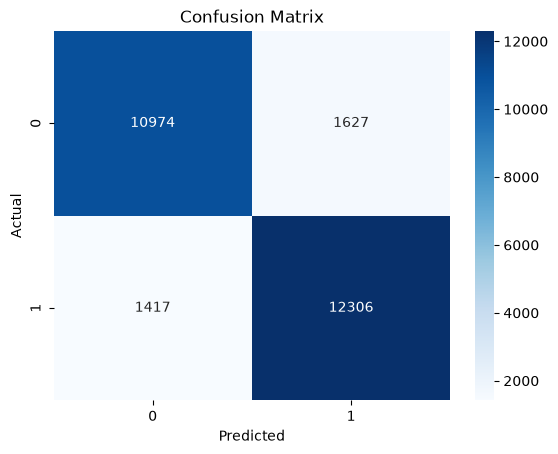

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

# 3.Clustering

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

features = [
    'current_score',
    'wickets_down',
    'balls_remaining',
    'current_run_rate',
    'required_run_rate'
]

cluster_data = df[features].copy()

cluster_data = cluster_data.replace(
    [float('inf'), -float('inf')], None
)

cluster_data = cluster_data.dropna()

scaler = StandardScaler()

X_cluster = scaler.fit_transform(cluster_data)

# Elbow Method
the elbow method helps us decide the suitable number of clusters

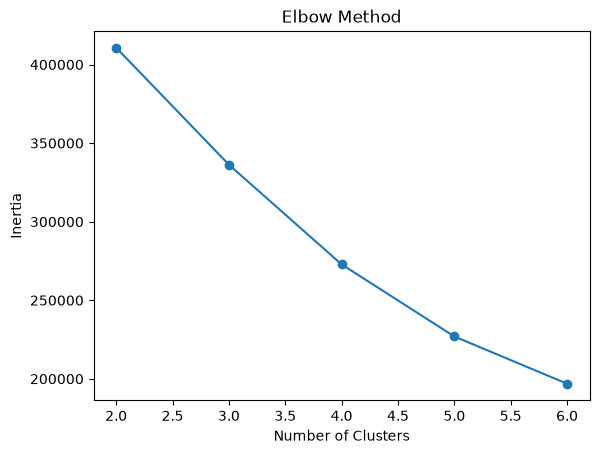

In [5]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []

for k in range(2, 7):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X_cluster)

    inertia.append(model.inertia_)

plt.plot(range(2, 7), inertia, marker='o')

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# Silhouette Score
it tells us how well the observations fit their clusters

In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Select features
features = [
    'current_score',
    'wickets_down',
    'balls_remaining',
    'current_run_rate',
    'required_run_rate'
]

# Remove missing values
data = df[features].dropna()

# Scale the data
scaler = StandardScaler()
X_cluster = scaler.fit_transform(data)

# Create 3 clusters
model = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

labels = model.fit_predict(X_cluster)

# Take only 2000 rows for Silhouette Score
sample_size = min(2000, len(X_cluster))

score = silhouette_score(
    X_cluster[:sample_size],
    labels[:sample_size]
)

print("Silhouette Score:", score)

Silhouette Score: 0.3917081810667929


# Cluster visualization


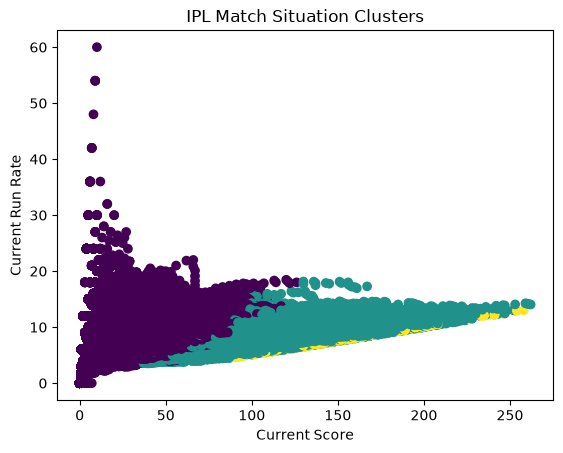

In [8]:
import matplotlib.pyplot as plt

plt.scatter(
    cluster_data['current_score'],
    cluster_data['current_run_rate'],
    c=labels,
    cmap='viridis'
)

plt.xlabel("Current Score")
plt.ylabel("Current Run Rate")
plt.title("IPL Match Situation Clusters")

plt.show()